# 03 - Economic Optimization Analysis

This notebook analyzes the results of the solar and battery economic optimization.

The goal is to compare different photovoltaic and battery configurations according to:

- Investment cost
- Annual savings
- Payback period
- Grid electricity imports
- Solar surplus
- Self-sufficiency

The main idea is to understand the trade-off between economic profitability and energy independence.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent

GRID_SEARCH_RESULTS_PATH = PROJECT_ROOT / "reports" / "grid_search_results.csv"
BEST_SCENARIOS_PATH = PROJECT_ROOT / "reports" / "best_scenarios.csv"

## Load optimization results

We load the full grid search results and the selected best scenarios.

In [2]:
grid_df = pd.read_csv(GRID_SEARCH_RESULTS_PATH)
best_df = pd.read_csv(BEST_SCENARIOS_PATH)

grid_df.head()

,solar_peak_power_kw,battery_capacity_kwh,investment_cost_eur,period_cost_eur,annual_cost_eur,period_savings_eur,annual_savings_eur,payback_years,grid_import_kwh,solar_surplus_kwh,potential_surplus_compensation_eur,self_sufficiency
0,0.5,0.0,1250.0,35.843282,436.093267,10.253449,124.750294,10.020016,181.692102,7.073401,0.495138,0.211692
1,0.5,0.5,1500.0,35.065208,426.626699,11.031523,134.216863,11.175943,175.326041,0.000000,0.000000,0.239312
2,0.5,1.0,1750.0,35.065208,426.626699,11.031523,134.216863,13.038600,175.326041,0.000000,0.000000,0.239312
3,0.5,2.0,2250.0,35.065208,426.626699,11.031523,134.216863,16.763914,175.326041,0.000000,0.000000,0.239312
4,0.5,3.0,2750.0,35.065208,426.626699,11.031523,134.216863,20.489229,175.326041,0.000000,0.000000,0.239312


## Solar data source

The optimization results analyzed in this notebook are generated using PVGIS-based solar generation data for Linares, Spain.

PVGIS provides an hourly photovoltaic production profile for a reference 1 kW PV system. The model scales this profile linearly to simulate different installed PV capacities.

For example:

- 0.5 kW PV system = PVGIS 1 kW profile × 0.5
- 1.5 kW PV system = PVGIS 1 kW profile × 1.5
- 3.0 kW PV system = PVGIS 1 kW profile × 3.0

This makes the solar generation profile more realistic than the initial synthetic daily curve.

In [3]:
grid_df.columns

Index(['solar_peak_power_kw', 'battery_capacity_kwh', 'investment_cost_eur',
       'period_cost_eur', 'annual_cost_eur', 'period_savings_eur',
       'annual_savings_eur', 'payback_years', 'grid_import_kwh',
       'solar_surplus_kwh', 'potential_surplus_compensation_eur',
       'self_sufficiency'],
      dtype='str')

In [4]:
grid_df[
    [
        "solar_peak_power_kw",
        "battery_capacity_kwh",
        "grid_import_kwh",
        "solar_surplus_kwh",
        "annual_savings_eur",
        "payback_years",
        "self_sufficiency"
    ]
].head()

,solar_peak_power_kw,battery_capacity_kwh,grid_import_kwh,solar_surplus_kwh,annual_savings_eur,payback_years,self_sufficiency
0,0.5,0.0,181.692102,7.073401,124.750294,10.020016,0.211692
1,0.5,0.5,175.326041,0.000000,134.216863,11.175943,0.239312
2,0.5,1.0,175.326041,0.000000,134.216863,13.038600,0.239312
3,0.5,2.0,175.326041,0.000000,134.216863,16.763914,0.239312
4,0.5,3.0,175.326041,0.000000,134.216863,20.489229,0.239312


## Grid search overview

Each row represents one solar and battery configuration.

In [5]:
print(f"Number of scenarios: {len(grid_df)}")
print(f"Solar peak power values: {sorted(grid_df['solar_peak_power_kw'].unique())}")
print(f"Battery capacity values: {sorted(grid_df['battery_capacity_kwh'].unique())}")

Number of scenarios: 30
Solar peak power values: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(3.0)]
Battery capacity values: [np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0)]


## Best scenario by payback

The best economic scenario is the one with the minimum payback period.

In [6]:
best_payback = best_df[best_df["criterion"] == "best_payback"].iloc[0]

best_payback

criterion               best_payback
solar_peak_power_kw              2.0
battery_capacity_kwh             0.0
investment_cost_eur           2600.0
annual_savings_eur        300.620922
payback_years               8.648766
self_sufficiency            0.302587
grid_import_kwh           160.742259
solar_surplus_kwh         153.718424
Name: 0, dtype: object

This scenario minimizes the time needed to recover the initial investment through annual savings.

## Best scenario by self-sufficiency

The best energy scenario is the one with the highest self-sufficiency.

In [7]:
best_self_sufficiency = best_df[
    best_df["criterion"] == "best_self_sufficiency"
].iloc[0]

best_self_sufficiency

criterion               best_self_sufficiency
solar_peak_power_kw                       3.0
battery_capacity_kwh                      5.0
investment_cost_eur                    6000.0
annual_savings_eur                 560.843562
payback_years                        10.69817
self_sufficiency                     0.890673
grid_import_kwh                     25.198161
solar_surplus_kwh                  113.775169
Name: 1, dtype: object

This scenario maximizes the percentage of household electricity demand covered by the solar and battery system.

## Economic optimum vs energy optimum

We compare the two selected scenarios.

In [8]:
comparison_columns = [
    "criterion",
    "solar_peak_power_kw",
    "battery_capacity_kwh",
    "investment_cost_eur",
    "annual_savings_eur",
    "payback_years",
    "self_sufficiency",
    "grid_import_kwh",
    "solar_surplus_kwh"
]

best_df[comparison_columns]

,criterion,solar_peak_power_kw,battery_capacity_kwh,investment_cost_eur,annual_savings_eur,payback_years,self_sufficiency,grid_import_kwh,solar_surplus_kwh
0,best_payback,2.0,0.0,2600.0,300.620922,8.648766,0.302587,160.742259,153.718424
1,best_self_sufficiency,3.0,5.0,6000.0,560.843562,10.698170,0.890673,25.198161,113.775169


## Payback period by solar power and battery capacity

This plot shows how the payback period changes across different solar and battery configurations.

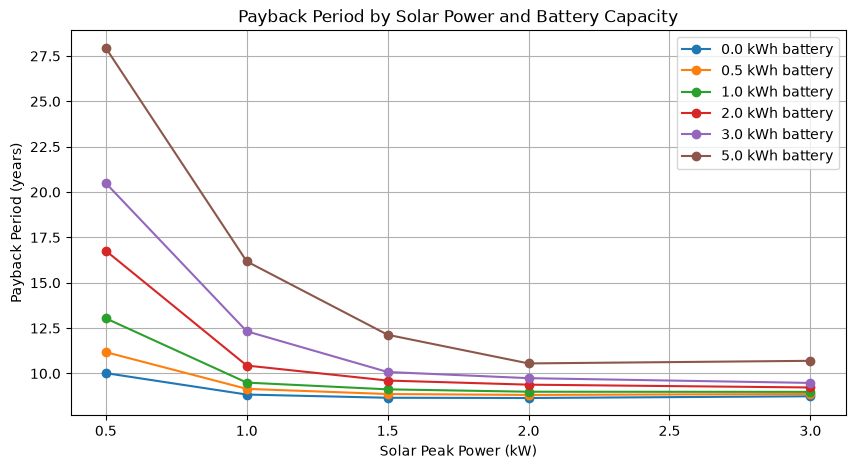

In [9]:
plt.figure(figsize=(10, 5))

for battery_capacity_kwh in sorted(grid_df["battery_capacity_kwh"].unique()):
    battery_df = grid_df[
        grid_df["battery_capacity_kwh"] == battery_capacity_kwh
    ]

    plt.plot(
        battery_df["solar_peak_power_kw"],
        battery_df["payback_years"],
        marker="o",
        label=f"{battery_capacity_kwh} kWh battery"
    )

plt.title("Payback Period by Solar Power and Battery Capacity")
plt.xlabel("Solar Peak Power (kW)")
plt.ylabel("Payback Period (years)")
plt.grid(True)
plt.legend()

plt.show()

## Self-sufficiency by solar power and battery capacity

This plot shows how increasing solar power and battery capacity affects energy independence.

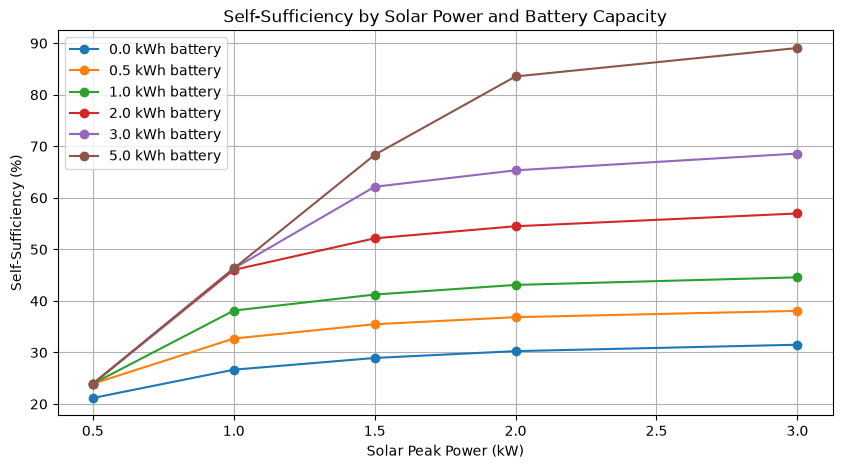

In [10]:
plt.figure(figsize=(10, 5))

for battery_capacity_kwh in sorted(grid_df["battery_capacity_kwh"].unique()):
    battery_df = grid_df[
        grid_df["battery_capacity_kwh"] == battery_capacity_kwh
    ]

    plt.plot(
        battery_df["solar_peak_power_kw"],
        battery_df["self_sufficiency"] * 100,
        marker="o",
        label=f"{battery_capacity_kwh} kWh battery"
    )

plt.title("Self-Sufficiency by Solar Power and Battery Capacity")
plt.xlabel("Solar Peak Power (kW)")
plt.ylabel("Self-Sufficiency (%)")
plt.grid(True)
plt.legend()

plt.show()

## Payback vs self-sufficiency

This scatter plot shows the trade-off between economic profitability and energy independence.

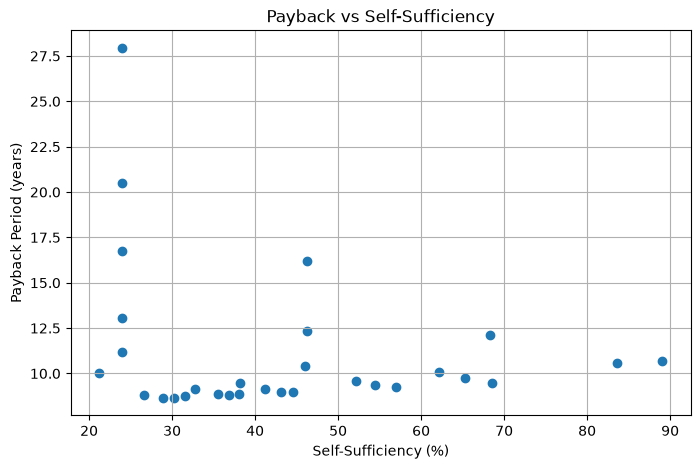

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    grid_df["self_sufficiency"] * 100,
    grid_df["payback_years"]
)

plt.title("Payback vs Self-Sufficiency")
plt.xlabel("Self-Sufficiency (%)")
plt.ylabel("Payback Period (years)")
plt.grid(True)

plt.show()

## Investment cost vs annual savings

Higher investment can increase savings, but it does not always lead to a shorter payback period.

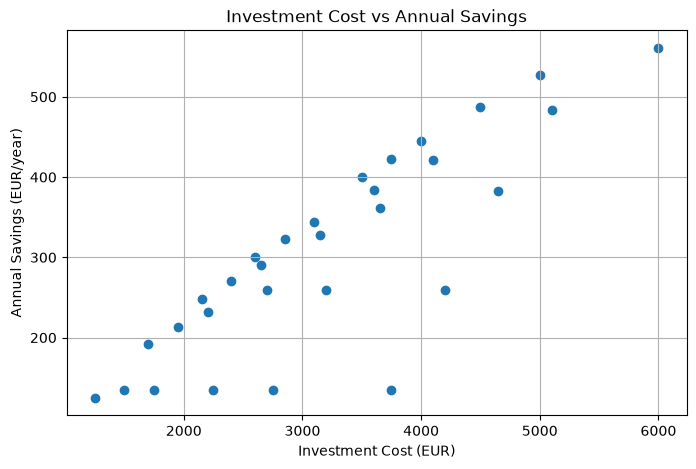

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    grid_df["investment_cost_eur"],
    grid_df["annual_savings_eur"]
)

plt.title("Investment Cost vs Annual Savings")
plt.xlabel("Investment Cost (EUR)")
plt.ylabel("Annual Savings (EUR/year)")
plt.grid(True)

plt.show()

## Top scenarios by payback

The following table shows the configurations with the shortest payback period.

In [13]:
grid_df.sort_values("payback_years").head(10)[
    [
        "solar_peak_power_kw",
        "battery_capacity_kwh",
        "investment_cost_eur",
        "annual_savings_eur",
        "payback_years",
        "self_sufficiency"
    ]
]

,solar_peak_power_kw,battery_capacity_kwh,investment_cost_eur,annual_savings_eur,payback_years,self_sufficiency
18,2.0,0.0,2600.0,300.620922,8.648766,0.302587
12,1.5,0.0,2150.0,248.217907,8.661744,0.289352
24,3.0,0.0,3500.0,400.312705,8.743165,0.315028
19,2.0,0.5,2850.0,323.203207,8.817982,0.368475
6,1.0,0.0,1700.0,192.335248,8.838734,0.266573
13,1.5,0.5,2400.0,270.657512,8.867295,0.354824
25,3.0,0.5,3750.0,422.822901,8.868961,0.380705
26,3.0,1.0,4000.0,445.128457,8.986170,0.445786
20,2.0,1.0,3100.0,344.655401,8.994491,0.431066
14,1.5,1.0,2650.0,290.377483,9.126052,0.412361


## Top scenarios by self-sufficiency

The following table shows the configurations with the highest self-sufficiency.

In [14]:
grid_df.sort_values("self_sufficiency", ascending=False).head(10)[
    [
        "solar_peak_power_kw",
        "battery_capacity_kwh",
        "investment_cost_eur",
        "annual_savings_eur",
        "payback_years",
        "self_sufficiency"
    ]
]

,solar_peak_power_kw,battery_capacity_kwh,investment_cost_eur,annual_savings_eur,payback_years,self_sufficiency
29,3.0,5.0,6000.0,560.843562,10.698170,0.890673
23,2.0,5.0,5100.0,483.204092,10.554546,0.835480
28,3.0,3.0,5000.0,527.425132,9.480018,0.685901
17,1.5,5.0,4650.0,383.260900,12.132727,0.683365
22,2.0,3.0,4100.0,420.838487,9.742455,0.653344
16,1.5,3.0,3650.0,362.053072,10.081395,0.621487
27,3.0,2.0,4500.0,487.591611,9.229035,0.569680
21,2.0,2.0,3600.0,383.662561,9.383246,0.544876
15,1.5,2.0,3150.0,327.764804,9.610550,0.521445
10,1.0,3.0,3200.0,259.639058,12.324802,0.462944


## Conclusions

The optimization is now based on PVGIS hourly solar generation data for Linares, Spain, rather than a purely synthetic solar curve.

This improves the realism of the solar production profile because the PVGIS data includes location-specific seasonal and hourly solar behavior.

The results still depend on simplified assumptions such as constant electricity price, constant surplus compensation, no degradation and synthetic household consumption. However, using PVGIS data is an important step towards a more realistic residential solar optimization model.